# Headline Bias Analysis — FinBERT Sentiment Divergence

This notebook performs a formal statistical analysis of the headline bias finding
identified during Phase 2. Headline bias refers to the divergence between sentiment
signals extracted from article headlines alone versus headlines combined with body text.

The analysis is restricted to the articles that passed the body quality filter (7,755 in
the current corpus), as these are the only cases where a genuine comparison between
title-only and title+body sentiment is possible. Two lenses are used: a discrete lens on
FinBERT's argmax label (chi-square, transition breakdown) and a continuous lens on the
full FinBERT probability distribution (divergence magnitude and its signed direction).

# General inputs

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [2]:
## Load sentiment dataset
df = pd.read_csv("../01_data/features/gdelt_wti_sentiment.csv", parse_dates=['datetime'])

# Work only with articles that have valid body — these are the ones where divergence is meaningful
df_valid = df[df['body_valid'] == True].copy().reset_index(drop=True)

print(f"Total articles: {len(df)}")
print(f"Articles with valid body: {len(df_valid)}")
print(f"\nTitle sentiment distribution:")
print(df_valid['title_sentiment'].value_counts())
print(f"\nFull sentiment distribution:")
print(df_valid['full_sentiment'].value_counts())

Total articles: 13690
Articles with valid body: 7755

Title sentiment distribution:
title_sentiment
negative    3071
positive    2427
neutral     2257
Name: count, dtype: int64

Full sentiment distribution:
full_sentiment
negative    4021
positive    2613
neutral     1121
Name: count, dtype: int64


### Chi-square test
Tests whether the sentiment distribution changes significantly when body text is added 
to the input. The null hypothesis is that title-only and title+body sentiment are drawn 
from the same distribution — i.e. that headlines are an unbiased representation of the 
full article sentiment. Rejecting the null hypothesis provides statistical evidence that 
headlines systematically misrepresent article sentiment, which is the core claim of the 
headline bias finding.

### Divergence direction breakdown
Analyzes which sentiment transitions are most frequent (e.g. neutral→negative, 
positive→negative) to identify whether the bias is directional — for instance, 
whether headlines tend to be systematically more positive or more neutral than 
the full article content.

### Confidence score comparison
Compares FinBERT's confidence scores between title-only and title+body inputs. 
If adding body text consistently increases confidence, it suggests the body 
provides genuine disambiguating information rather than noise.

In [3]:
# Cell 3 — Chi-square test
# Tests whether the distribution of sentiment changes significantly when body is added

contingency_table = pd.crosstab(
    df_valid['title_sentiment'], 
    df_valid['full_sentiment'],
    rownames=['Title sentiment'],
    colnames=['Full sentiment']
)

print("Contingency table (title vs full sentiment):")
print(contingency_table)

chi2, p, dof, expected = chi2_contingency(contingency_table)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"Degrees of freedom: {dof}")
print(f"p-value: {p:.6f}")
print(f"\nInterpretation: {'Distributions are significantly different (p < 0.05)' if p < 0.05 else 'No significant difference'}")

Contingency table (title vs full sentiment):
Full sentiment   negative  neutral  positive
Title sentiment                             
negative             2402      169       500
neutral               893      688       676
positive              726      264      1437

Chi-square statistic: 2050.1465
Degrees of freedom: 4
p-value: 0.000000

Interpretation: Distributions are significantly different (p < 0.05)


In [4]:
# Cell 4 — Divergence direction breakdown
total_valid = len(df_valid)

print("=== Divergence Direction Breakdown ===\n")
transitions = []
for title_s in ['positive', 'neutral', 'negative']:
    for full_s in ['positive', 'neutral', 'negative']:
        if title_s != full_s:
            count = contingency_table.loc[title_s, full_s]
            pct_of_total = count / total_valid * 100
            pct_of_title = count / contingency_table.loc[title_s].sum() * 100
            transitions.append({
                'transition': f"{title_s} → {full_s}",
                'count': count,
                'pct_of_total': round(pct_of_total, 1),
                'pct_of_title_class': round(pct_of_title, 1)
            })

df_transitions = pd.DataFrame(transitions).sort_values('count', ascending=False)
print(df_transitions.to_string(index=False))

=== Divergence Direction Breakdown ===

         transition  count  pct_of_total  pct_of_title_class
 neutral → negative    893          11.5                39.6
positive → negative    726           9.4                29.9
 neutral → positive    676           8.7                30.0
negative → positive    500           6.4                16.3
 positive → neutral    264           3.4                10.9
 negative → neutral    169           2.2                 5.5


In [5]:
# Cell 5 — Confidence score comparison
print("=== Confidence Score Comparison ===\n")

print("Average confidence by input type:")
print(f"Title-only:   {df_valid['title_confidence'].mean():.4f}")
print(f"Title+body:   {df_valid['full_confidence'].mean():.4f}")

print("\nAverage confidence for DIVERGENT articles:")
df_div = df_valid[df_valid['title_sentiment'] != df_valid['full_sentiment']]
print(f"Title-only:   {df_div['title_confidence'].mean():.4f}")
print(f"Title+body:   {df_div['full_confidence'].mean():.4f}")

print("\nAverage confidence for AGREEING articles:")
df_agree = df_valid[df_valid['title_sentiment'] == df_valid['full_sentiment']]
print(f"Title-only:   {df_agree['title_confidence'].mean():.4f}")
print(f"Title+body:   {df_agree['full_confidence'].mean():.4f}")

=== Confidence Score Comparison ===

Average confidence by input type:
Title-only:   0.8141
Title+body:   0.8552

Average confidence for DIVERGENT articles:
Title-only:   0.7781
Title+body:   0.8266

Average confidence for AGREEING articles:
Title-only:   0.8398
Title+body:   0.8755


### Continuous divergence magnitude

The chi-square and transition analyses above operate on FinBERT's argmax label, so they
only register a divergence when the headline and the full text fall in different boxes.
That misses two things: how far the sentiment moved (a neutral->negative flip and a
strong-positive->strong-negative flip both count as a single flip), and shifts inside
articles that keep the same label but still move substantially.

To capture both, we define a signed sentiment on [-1, +1] for each input as
`P(positive) - P(negative)` and measure the divergence magnitude as
`|signed_full - signed_title|`. This uses the full FinBERT distribution rather than the
hard label, and the sign of the shift tells us the direction of the headline bias.

In [6]:
# Cell 5b — Continuous divergence magnitude (full FinBERT distribution, not just labels)
df_valid['signed_title'] = df_valid['title_score_positive'] - df_valid['title_score_negative']
df_valid['signed_full']  = df_valid['full_score_positive']  - df_valid['full_score_negative']
df_valid['divergence_magnitude'] = (df_valid['signed_full'] - df_valid['signed_title']).abs()

df_flip = df_valid[df_valid['title_sentiment'] != df_valid['full_sentiment']]
df_same = df_valid[df_valid['title_sentiment'] == df_valid['full_sentiment']]

print("=== Continuous divergence magnitude  |signed_full - signed_title| ===\n")
print(f"All valid-body : mean={df_valid['divergence_magnitude'].mean():.4f}  median={df_valid['divergence_magnitude'].median():.4f}")
print(f"Label-flip     : mean={df_flip['divergence_magnitude'].mean():.4f}  median={df_flip['divergence_magnitude'].median():.4f}  (n={len(df_flip)})")
print(f"Same-label     : mean={df_same['divergence_magnitude'].mean():.4f}  median={df_same['divergence_magnitude'].median():.4f}  (n={len(df_same)})")

# Sentiment movement the discrete label test cannot see
shift_same = (df_same['divergence_magnitude'] > 0.2).mean() * 100
print(f"\nSame-label articles with a non-trivial shift (>0.2): {shift_same:.1f}%")
print("The label test scores these as agreement, yet the body still moved the sentiment.")

# Direction of the bias
mean_shift = (df_valid['signed_full'] - df_valid['signed_title']).mean()
direction = 'body more bearish than headline' if mean_shift < 0 else 'body more bullish than headline'
print(f"\nMean signed shift (full - title): {mean_shift:+.4f}  ({direction})")

=== Continuous divergence magnitude  |signed_full - signed_title| ===

All valid-body : mean=0.5028  median=0.3250
Label-flip     : mean=0.9627  median=0.9016  (n=3228)
Same-label     : mean=0.1749  median=0.0916  (n=4527)

Same-label articles with a non-trivial shift (>0.2): 31.6%
The label test scores these as agreement, yet the body still moved the sentiment.

Mean signed shift (full - title): -0.0897  (body more bearish than headline)


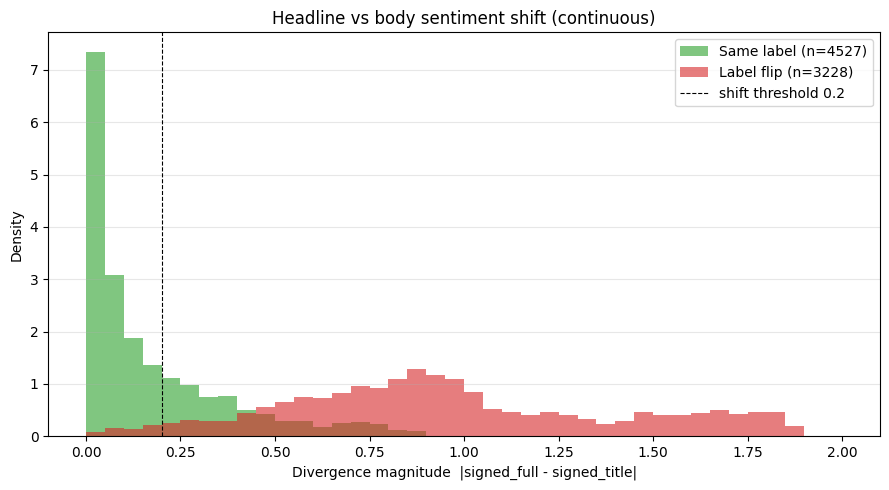

Saved to 04_outputs/figures/headline_bias_divergence_magnitude.png


In [7]:
# Cell 5c — Distribution of the continuous divergence magnitude
fig, ax = plt.subplots(figsize=(9, 5))
bins = np.linspace(0, 2, 41)
ax.hist(df_same['divergence_magnitude'], bins=bins, density=True, alpha=0.6,
        color='#2ca02c', label=f'Same label (n={len(df_same)})')
ax.hist(df_flip['divergence_magnitude'], bins=bins, density=True, alpha=0.6,
        color='#d62728', label=f'Label flip (n={len(df_flip)})')
ax.axvline(0.2, color='black', linestyle='--', linewidth=0.8, label='shift threshold 0.2')
ax.set_xlabel('Divergence magnitude  |signed_full - signed_title|')
ax.set_ylabel('Density')
ax.set_title('Headline vs body sentiment shift (continuous)')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig("../04_outputs/figures/headline_bias_divergence_magnitude.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/headline_bias_divergence_magnitude.png")

The continuous view sharpens the headline-bias finding. Label flips correspond to near-full
sentiment reversals (mean magnitude close to 1), but a substantial share of same-label
articles also shift non-trivially, so the discrete flip rate understates how much the body
revises the headline. The mean signed shift is negative: adding body text makes FinBERT's
sentiment systematically more bearish than the headline alone, i.e. headlines lean more
bullish than the articles they head. This is the direction of bias the label test cannot
express, and it motivates title+body as the primary input.

### Visualize divergence cases

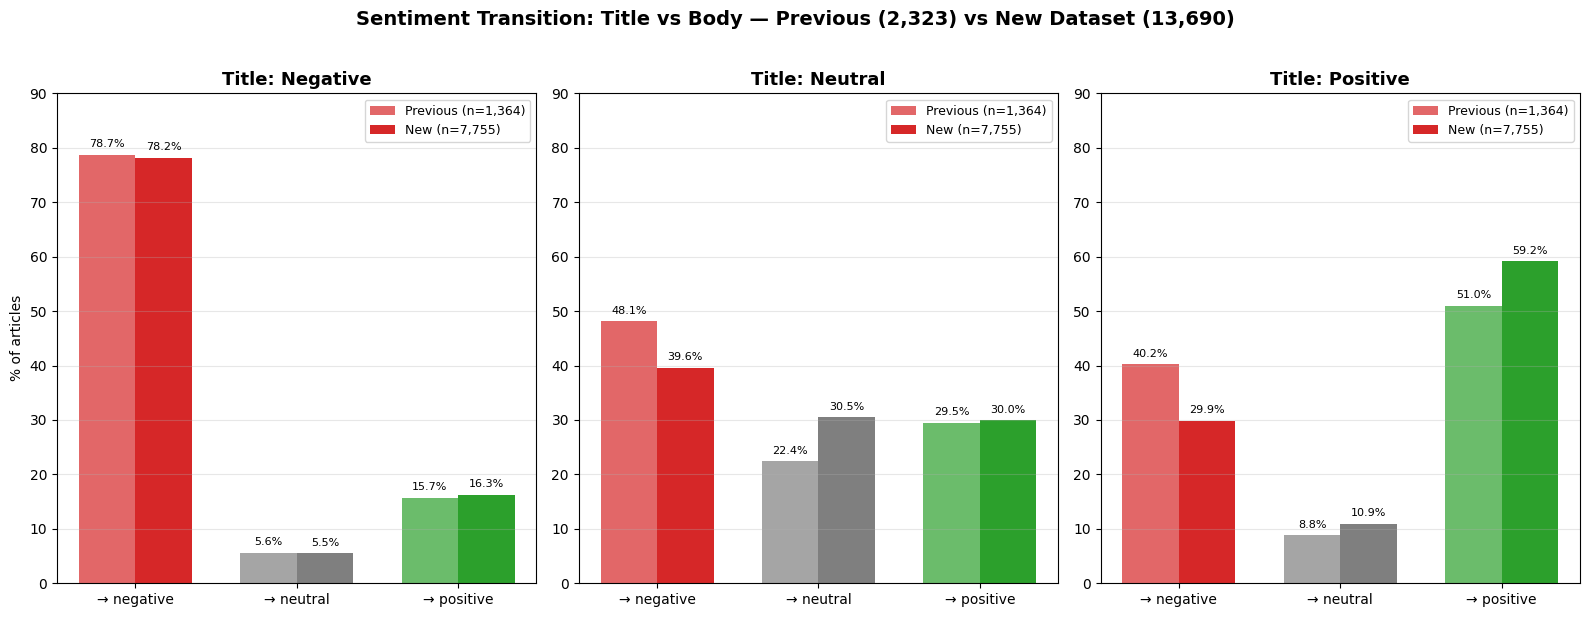

Saved to 04_outputs/figures/headline_bias_comparison.png


In [8]:
# Celda — Visualization of sentiment transitions

fig, axes = plt.subplots(1, 3, figsize=(16, 6))

categories = ['negative', 'neutral', 'positive']
colors_prev = ['#d62728', '#aec7e8', '#2ca02c']
colors_new = ['#ff7f0e', '#1f77b4', '#98df8a']

# Previous dataset proportions
prev_data = {
    'negative': [78.7, 5.6, 15.7],
    'neutral':  [48.1, 22.4, 29.5],
    'positive': [40.2, 8.8, 51.0]
}

# New dataset proportions
new_data = {
    'negative': [78.2, 5.5, 16.3],
    'neutral':  [39.6, 30.5, 30.0],
    'positive': [29.9, 10.9, 59.2]
}

labels = ['→ negative', '→ neutral', '→ positive']
x = np.arange(len(labels))
width = 0.35

for idx, title_sent in enumerate(categories):
    ax = axes[idx]
    bars1 = ax.bar(x - width/2, prev_data[title_sent], width, 
                   label='Previous (n=1,364)', color=['#d62728', '#7f7f7f', '#2ca02c'], alpha=0.7)
    bars2 = ax.bar(x + width/2, new_data[title_sent], width, 
                   label='New (n=7,755)', color=['#d62728', '#7f7f7f', '#2ca02c'], alpha=1.0)
    
    ax.set_title(f'Title: {title_sent.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=10)
    ax.set_ylabel('% of articles' if idx == 0 else '')
    ax.set_ylim(0, 90)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3, axis='y')

    # Add value labels on bars
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Sentiment Transition: Title vs Body — Previous (2,323) vs New Dataset (13,690)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig("../04_outputs/figures/headline_bias_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved to 04_outputs/figures/headline_bias_comparison.png")

### Interpretation — Sentiment Transition Comparison

The chart shows how body text changes FinBERT's sentiment classification 
relative to the headline alone, comparing the previous small dataset (n=1,364) 
against the expanded dataset (n=7,755). The consistency across both datasets 
confirms the headline bias finding is robust and not a small-sample artifact.

**Negative titles (left panel)** are the most reliable — approximately 78% of 
articles with a negative headline also have negative body sentiment in both 
datasets. The transition pattern is nearly identical between previous and new, 
indicating that bearish headlines are generally accurate representations of 
article content.

**Neutral titles (center panel)** show the most interesting shift between 
datasets. In the previous dataset, 48.1% of neutral headlines masked bearish 
body content. In the expanded dataset this drops to 39.6%, while neutral-to-neutral 
agreement improves from 22.4% to 30.5%. This suggests that with more data, 
FinBERT better distinguishes genuinely neutral articles from those with a 
misleading neutral headline.

**Positive titles (right panel)** show the largest improvement in reliability. 
Agreement between positive headline and positive body increased from 51.0% to 
59.2%, while the dangerous positive-to-negative divergence dropped from 40.2% 
to 29.9%. With a larger and more diverse dataset, bullish headlines are more 
likely to reflect genuinely bullish content.

**Overall conclusion:** The headline bias finding replicates consistently across 
both datasets. Neutral and positive headlines remain the least reliable sentiment 
signals, while negative headlines are consistently accurate. This justifies using 
title+body as the primary FinBERT input and motivates caution when interpreting 
headline-only sentiment in financial NLP applications.

In [9]:
# Cell 6 — Save headline bias summary stats
total_articles = len(df)
total_valid = len(df_valid)

# Compute divergence from contingency table
agreement_valid = int(np.diag(contingency_table.values).sum())
divergence_valid = total_valid - agreement_valid

summary = {
    'total_articles': total_articles,
    'total_valid_body': total_valid,
    'divergence_count': divergence_valid,
    'divergence_rate_valid_body': round(divergence_valid / total_valid, 4),
    'divergence_rate_overall': round(divergence_valid / total_articles, 4),
    'chi2_statistic': round(chi2, 4),
    'chi2_pvalue': round(p, 6),
    'chi2_dof': dof,
    'confidence_title_only': round(df_valid['title_confidence'].mean(), 4),
    'confidence_full': round(df_valid['full_confidence'].mean(), 4),
    'divergent_confidence_title': round(df_div['title_confidence'].mean(), 4),
    'divergent_confidence_full': round(df_div['full_confidence'].mean(), 4),
    # Continuous divergence (full FinBERT distribution, signed = P(pos) - P(neg))
    'div_magnitude_mean_all': round(df_valid['divergence_magnitude'].mean(), 4),
    'div_magnitude_mean_flip': round(df_flip['divergence_magnitude'].mean(), 4),
    'div_magnitude_mean_same': round(df_same['divergence_magnitude'].mean(), 4),
    'same_label_shift_gt_0p2_pct': round((df_same['divergence_magnitude'] > 0.2).mean() * 100, 1),
    'mean_signed_shift_full_minus_title': round((df_valid['signed_full'] - df_valid['signed_title']).mean(), 4),
}

pd.DataFrame([summary]).to_csv("../01_data/features/headline_bias_summary.csv", index=False)
print("Headline bias summary saved.")
print(pd.DataFrame([summary]).T)
print("\nMethodological decision: title+body sentiment selected as primary NLP input.")

Headline bias summary saved.
                                             0
total_articles                      13690.0000
total_valid_body                     7755.0000
divergence_count                     3228.0000
divergence_rate_valid_body              0.4162
divergence_rate_overall                 0.2358
chi2_statistic                       2050.1465
chi2_pvalue                             0.0000
chi2_dof                                4.0000
confidence_title_only                   0.8141
confidence_full                         0.8552
divergent_confidence_title              0.7781
divergent_confidence_full               0.8266
div_magnitude_mean_all                  0.5028
div_magnitude_mean_flip                 0.9627
div_magnitude_mean_same                 0.1749
same_label_shift_gt_0p2_pct            31.6000
mean_signed_shift_full_minus_title     -0.0897

Methodological decision: title+body sentiment selected as primary NLP input.
